# Regularizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
from torchvision import datasets, transforms

In [ ]:
train = datasets.MNIST( # MNIST 학습 데이터 로드
    '../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(), # 이미지를 텐서로 변환
    ]),
)
test = datasets.MNIST( # MNIST 테스트 데이터 로드
    '../data', train=False,
    transform=transforms.Compose([
        transforms.ToTensor(), # 이미지를 텐서로 변환
    ]),
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.59MB/s]


In [ ]:
x = train.data.float() / 255. # 데이터를 0~1 사이로 정규화
y = train.targets # 정답 데이터 추출

x = x.view(x.size(0), -1) # 입력 이미지를 1차원 배열로 평탄화
print(x.shape, y.shape)

input_size = x.size(-1) # 입력 차원 크기 확인 (784)
output_size = int(max(y)) + 1 # 출력 클래스 개수 계산 (10)

print('input_size: %d, output_size: %d' % (input_size, output_size))

torch.Size([60000, 784]) torch.Size([60000])
input_size: 784, output_size: 10


In [ ]:
# Train / Valid ratio
ratios = [.8, .2] # 학습 데이터와 검증 데이터 분할 비율

train_cnt = int(x.size(0) * ratios[0]) # 학습 데이터 개수
valid_cnt = int(x.size(0) * ratios[1]) # 검증 데이터 개수
test_cnt = len(test.data) # 테스트 데이터 개수
cnts = [train_cnt, valid_cnt] # 분할 개수 리스트

print("Train %d / Valid %d / Test %d samples." % (train_cnt, valid_cnt, test_cnt))

indices = torch.randperm(x.size(0)) # 무작위 인덱스 순서 생성

x = torch.index_select(x, dim=0, index=indices) # 데이터를 무작위로 재배치
y = torch.index_select(y, dim=0, index=indices) # 레이블을 무작위로 재배치

x = list(x.split(cnts, dim=0)) # 데이터를 학습/검증용으로 분할
y = list(y.split(cnts, dim=0)) # 레이블을 학습/검증용으로 분할

x += [(test.data.float() / 255.).view(test_cnt, -1)] # 테스트 데이터 추가
y += [test.targets] # 테스트 레이블 추가

for x_i, y_i in zip(x, y):
    print(x_i.size(), y_i.size())

Train 48000 / Valid 12000 / Test 10000 samples.
torch.Size([48000, 784]) torch.Size([48000])
torch.Size([12000, 784]) torch.Size([12000])
torch.Size([10000, 784]) torch.Size([10000])


## Build Regularized Model & Optimizer

In [ ]:
class Block(nn.Module): # 정규화 기능을 포함한 신경망 블록 정의
    
    def __init__(self,
                 input_size,
                 output_size,
                 use_batch_norm=True,
                 dropout_p=.4):
        self.input_size = input_size # 입력 크기 저장
        self.output_size = output_size # 출력 크기 저장
        self.use_batch_norm = use_batch_norm # 배치 정규화 사용 여부
        self.dropout_p = dropout_p # 드롭아웃 확률 설정
        
        super().__init__() # 부모 클래스 초기화
        
        def get_regularizer(use_batch_norm, size): # 정규화 도구 선택기
            return nn.BatchNorm1d(size) if use_batch_norm else nn.Dropout(dropout_p)
        
        self.block = nn.Sequential( # 신경망 블록 레이어 구성
            nn.Linear(input_size, output_size), # 선형 변환 레이어
            nn.LeakyReLU(), # LeakyReLU 활성화 함수
            get_regularizer(use_batch_norm, output_size), # 배치 정규화 혹은 드롭아웃 적용
        )
        
    def forward(self, x): # 순전파 동작 정의
        # |x| = (batch_size, input_size)
        y = self.block(x)
        # |y| = (batch_size, output_size)
        
        return y # 계산된 텐서 반환

In [ ]:
class MyModel(nn.Module): # 전체 모델 구조 정의 클래스
    
    def __init__(self,
                 input_size,
                 output_size,
                 use_batch_norm=True,
                 dropout_p=.4):
        
        super().__init__() # 부모 클래스 초기화
        
        self.layers = nn.Sequential( # 블록들을 쌓아 깊은 신경망 구성
            Block(input_size, 500, use_batch_norm, dropout_p), # 은닉층 1
            Block(500, 400, use_batch_norm, dropout_p), # 은닉층 2
            Block(400, 300, use_batch_norm, dropout_p), # 은닉층 3
            Block(300, 200, use_batch_norm, dropout_p), # 은닉층 4
            Block(200, 100, use_batch_norm, dropout_p), # 은닉층 5
            nn.Linear(100, output_size), # 최종 선형 레이어
            nn.LogSoftmax(dim=-1), # 확률값 출력을 위한 LogSoftmax
        )
        
    def forward(self, x): # 순전파 동작
        # |x| = (batch_size, input_size)        
        y = self.layers(x)
        # |y| = (batch_size, output_size)
        
        return y # 신경망 출력 반환

In [ ]:
model = MyModel(input_size,
                output_size,
                use_batch_norm=True) # 모델 생성

model

MyModel(
  (layers): Sequential(
    (0): Block(
      (block): Sequential(
        (0): Linear(in_features=784, out_features=500, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): Block(
      (block): Sequential(
        (0): Linear(in_features=500, out_features=400, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): Block(
      (block): Sequential(
        (0): Linear(in_features=400, out_features=300, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (3): Block(
      (block): Sequential(
        (0): Linear(in_features=300, out_features=200, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(200, e

In [ ]:
crit = nn.NLLLoss() # 손실 함수 정의

In [ ]:
optimizer = optim.Adam(model.parameters()) # 최적화 알고리즘 설정

## Move to GPU if it is available

In [ ]:
device = torch.device('cpu') # GPU/CPU 설정
if torch.cuda.is_available():
    device = torch.device('cuda')

In [12]:
device

device(type='cuda')

In [ ]:
model = model.to(device) # 모델을 지정 기기로 전송

x = [x_i.to(device) for x_i in x] # 데이터들을 기기로 전송
y = [y_i.to(device) for y_i in y] # 레이블들을 기기로 전송

## Train

In [ ]:
n_epochs = 1000 # 최대 학습 횟수
batch_size = 256 # 한 번에 처리할 데이터 양
print_interval = 10 # 결과 출력 간격

In [ ]:
from copy import deepcopy # 객체 복사를 위한 모듈 임포트

lowest_loss = np.inf # 최소 손실 초기값 설정
best_model = None # 최적 모델 상태 저장 변수

early_stop = 50 # 조기 종료를 위한 에포크 수
lowest_epoch = np.inf # 최소 손실이 발생한 에포크 번호

In [ ]:
train_history, valid_history = [], [] # 손실 기록용 리스트

for i in range(n_epochs): # 학습 루프 시작
    model.train() # 학습 모드 전환
    
    indices = torch.randperm(x[0].size(0)).to(device) # 데이터 무작위 배치 준비
    x_ = torch.index_select(x[0], dim=0, index=indices) # 배치 분할
    y_ = torch.index_select(y[0], dim=0, index=indices) # 배치 분할
    
    x_ = x_.split(batch_size, dim=0) # 배치 분할
    y_ = y_.split(batch_size, dim=0) # 배치 분할
    
    train_loss, valid_loss = 0, 0 # 학습 손실 초기화
    y_hat = []
    
    for x_i, y_i in zip(x_, y_): # 미니 배치 반복
        y_hat_i = model(x_i) # 예측 수행
        loss = crit(y_hat_i, y_i.squeeze()) # 오차 계산

        optimizer.zero_grad() 
        loss.backward() 

        optimizer.step() # 역전파 및 가중치 업데이트
        train_loss += float(loss) # 손실 합산

    train_loss = train_loss / len(x_) # 에포크별 평균 학습 손실
        
    model.eval() # 검증 모드 전환
    with torch.no_grad(): # 기울기 계산 비활성화
        x_ = x[1].split(batch_size, dim=0) # 검증 데이터 배치 분할
        y_ = y[1].split(batch_size, dim=0) # 검증 레이블 배치 분할
        
        valid_loss = 0
        
        for x_i, y_i in zip(x_, y_): # 검증 반복
            y_hat_i = model(x_i) # 예측 수행
            loss = crit(y_hat_i, y_i.squeeze()) # 오차 계산
            
            valid_loss += float(loss) # 손실 합산
            
            y_hat += [y_hat_i]
            
    valid_loss = valid_loss / len(x_) # 에포크별 평균 학습 손실
    
    train_history += [train_loss] # 기록 저장
    valid_history += [valid_loss] # 기록 저장
        
    if (i + 1) % print_interval == 0:
        print('Epoch %d: train loss=%.4e  valid_loss=%.4e  lowest_loss=%.4e' % (
            i + 1,
            train_loss,
            valid_loss,
            lowest_loss,
        ))
        
    if valid_loss <= lowest_loss: # 최저 손실 경신 시
        lowest_loss = valid_loss # 값 업데이트
        lowest_epoch = i # 에포크 저장
        
        best_model = deepcopy(model.state_dict()) # 가중치 복사
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i + 1: # 성능 개선이 없으면
            print("There is no improvement during last %d epochs." % early_stop) # 알림 메시지
            break # 학습 조기 종료

print("The best validation loss from epoch %d: %.4e" % (lowest_epoch + 1, lowest_loss))
model.load_state_dict(best_model) # 학습된 최적 모델 로드

/tmp/ipykernel_3462/904865951.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  train_loss += float(loss) # This is very important to prevent memory leak.


Epoch 10: train loss=1.9304e-02  valid_loss=9.6817e-02  lowest_loss=8.0718e-02
Epoch 20: train loss=1.1132e-02  valid_loss=8.4279e-02  lowest_loss=8.0718e-02
Epoch 30: train loss=8.7830e-03  valid_loss=9.3495e-02  lowest_loss=7.5285e-02
Epoch 40: train loss=7.7813e-03  valid_loss=8.1244e-02  lowest_loss=7.5285e-02
Epoch 50: train loss=3.4570e-03  valid_loss=9.2008e-02  lowest_loss=7.5285e-02
Epoch 60: train loss=5.5637e-03  valid_loss=8.7612e-02  lowest_loss=7.5285e-02
Epoch 70: train loss=1.9564e-03  valid_loss=9.3594e-02  lowest_loss=7.5285e-02
There is no improvement during last 50 epochs.
The best validation loss from epoch 27: 7.5285e-02


<All keys matched successfully>

## Loss History

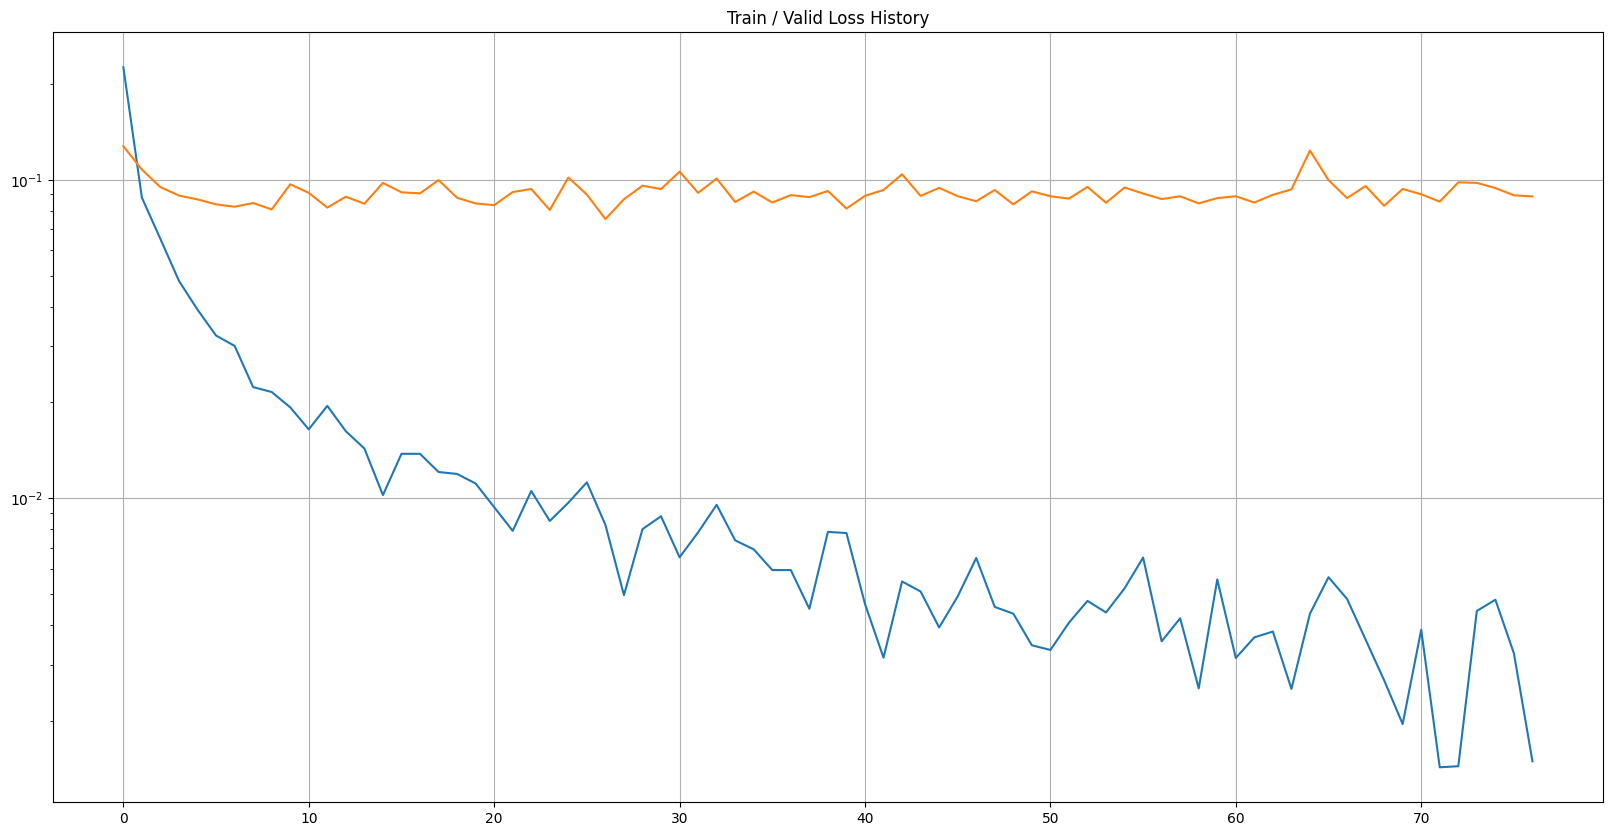

In [17]:
plot_from = 0

plt.figure(figsize=(20, 10))
plt.grid(True)
plt.title("Train / Valid Loss History")
plt.plot(
    range(plot_from, len(train_history)), train_history[plot_from:],
    range(plot_from, len(valid_history)), valid_history[plot_from:],
)
plt.yscale('log')
plt.show()

## Let's see the result!

In [ ]:
test_loss = 0
y_hat = []

model.eval() # 최종 평가 모드
with torch.no_grad(): # 테스트 데이터 검증
    x_ = x[-1].split(batch_size, dim=0) # 테스트 데이터 분할
    y_ = y[-1].split(batch_size, dim=0) # 테스트 레이블 분할

    for x_i, y_i in zip(x_, y_): # 테스트 수행
        y_hat_i = model(x_i) # 결과 도출
        loss = crit(y_hat_i, y_i.squeeze()) # 오차 계산

        test_loss += loss # 오차 합산

        y_hat += [y_hat_i] # 예측값 저장

test_loss = test_loss / len(x_)
y_hat = torch.cat(y_hat, dim=0) # 전체 예측값 병합

print("Test loss: %.4e" % test_loss)

Test loss: 7.3972e-02


In [ ]:
correct_cnt = (y[-1].squeeze() == torch.argmax(y_hat, dim=-1)).sum() # 정확도 계산
total_cnt = float(y[-1].size(0)) # 정확도 산출

print('Accuracy: %.4f' % (correct_cnt / total_cnt)) # 최종 정확도 출력

Accuracy: 0.9825


In [20]:
import pandas as pd
from sklearn.metrics import confusion_matrix

In [21]:
#pd.DataFrame(confusion_matrix(y[-1], torch.argmax(y_hat, dim=-1)),
#             index=['true_%d' % i for i in range(10)],
#             columns=['pred_%d' % i for i in range(10)])

pd.DataFrame(
    confusion_matrix(
        y[-1].cpu().numpy(),  # Tensor → NumPy 변환
        torch.argmax(y_hat, dim=-1).cpu().numpy()  # Tensor → NumPy 변환
    ),
    index=['true_%d' % i for i in range(10)],
    columns=['pred_%d' % i for i in range(10)]
)

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9
true_0,970,0,0,0,0,3,2,3,2,0
true_1,0,1123,3,1,0,1,2,1,4,0
true_2,6,1,1011,5,2,1,1,1,4,0
true_3,1,0,2,989,0,6,0,3,4,5
true_4,1,1,1,0,966,0,6,0,0,7
true_5,2,0,0,4,1,876,4,1,3,1
true_6,3,2,0,0,3,7,942,0,1,0
true_7,0,5,4,2,0,0,0,1010,1,6
true_8,3,0,1,4,0,4,0,2,954,6
true_9,3,2,0,2,8,5,0,4,1,984
